In [9]:
!git clone https://github.com/ifesiTinkering/LoRe_interp.git
%cd LoRe_interp
!pip install -q torch matplotlib numpy pillow


Cloning into 'LoRe_interp'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 150 (delta 29), reused 146 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 6.62 MiB | 11.09 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/LoRe_interp/LoRe_interp/LoRe_interp


In [7]:
!python plot_combined_heatmap.py


top panel saved to /content/LoRe_interp/LoRe_interp/out/user_weights_grid.png
[2026-05-21 11:10:04] Downloading conversations.jsonl from HuggingFace...
conversations.jsonl: 100% 60.3M/60.3M [00:01<00:00, 36.7MB/s]
[2026-05-21 11:10:06] Downloaded to /content/LoRe_interp/LoRe_interp/prism_cache/conversations.jsonl
[2026-05-21 11:10:06] Downloading survey.jsonl from HuggingFace...
survey.jsonl: 4.86MB [00:00, 41.5MB/s]
[2026-05-21 11:10:07] Downloaded to /content/LoRe_interp/LoRe_interp/prism_cache/survey.jsonl
[2026-05-21 11:10:07] Parsing PRISM survey data...
[2026-05-21 11:10:07] Parsed 1500 users from survey
[2026-05-21 11:10:07] Parsing PRISM conversation data...
[2026-05-21 11:10:08] Parsed 8011 dialogs from conversations
[2026-05-21 11:10:08] Splitting users with seed=123, seen_ratio=0.8, min_dialogs>5
[2026-05-21 11:10:08] Users with >5 dialogs: 1288
[2026-05-21 11:10:08] Seen users: 1030, Unseen users: 258
[2026-05-21 11:10:08] Train dialogs: 3864, Test dialogs: 3869
Traceback (

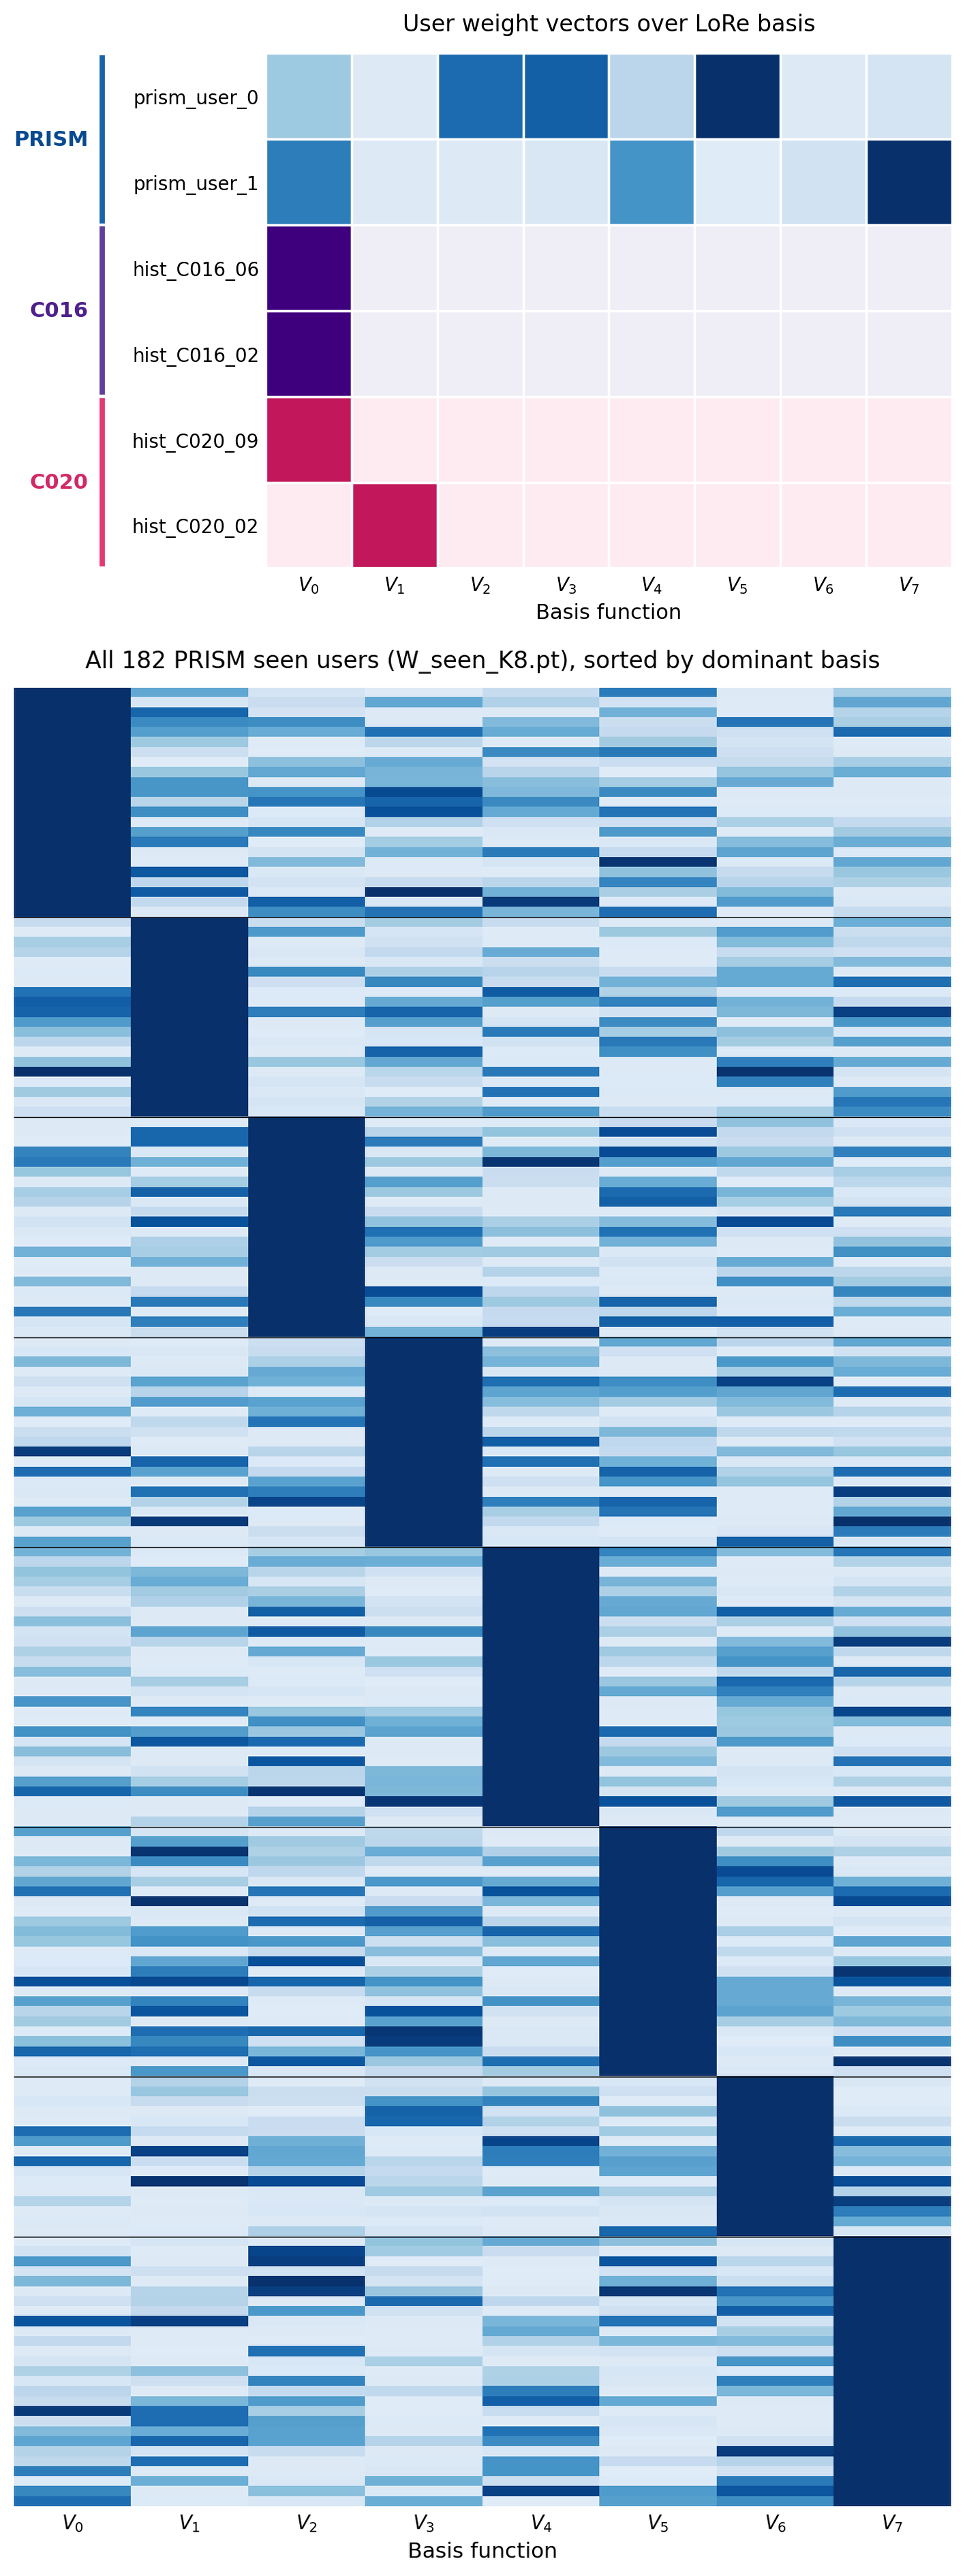

In [ ]:
from IPython.display import Image
Image('out/combined_heatmap.png')


Median dominance ratio: 1.41
Users with strong winner (>=3x): 9 / 182
Users with clear winner (>=2x): 39 / 182
Users with slight lean (>=1.5x): 76 / 182
Users effectively tied (<1.2x): 45 / 182


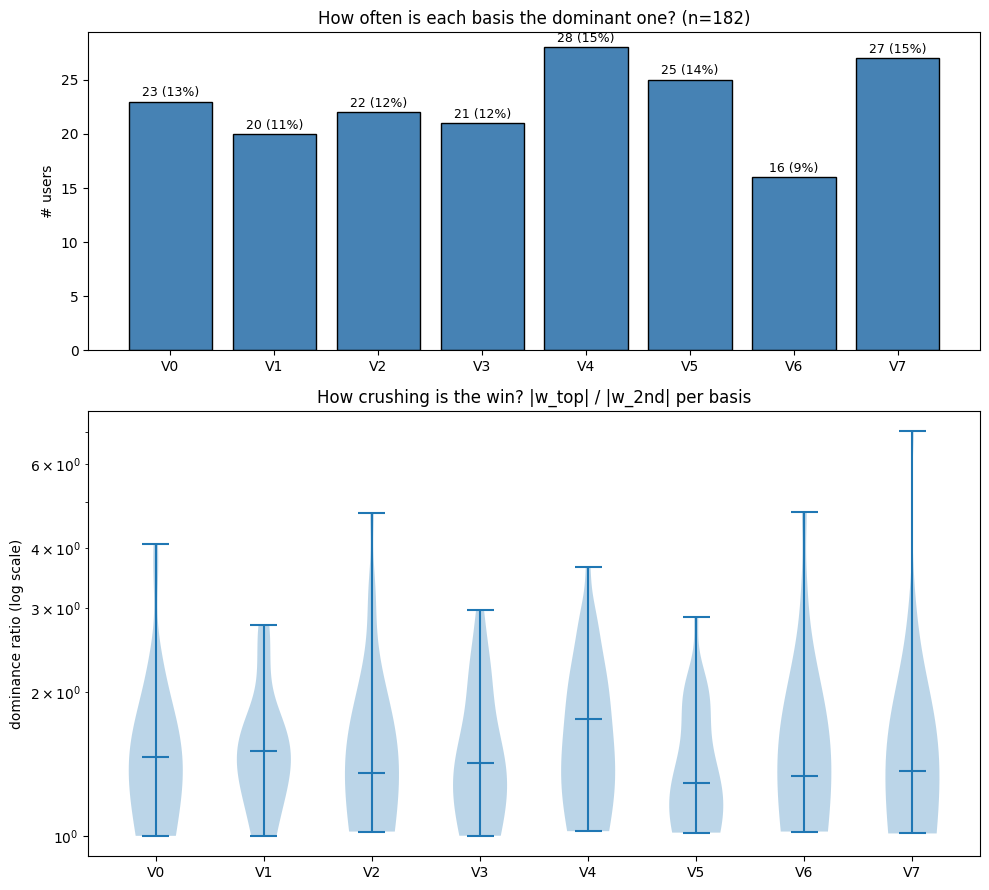

Median dominance ratio overall: 1.41
Users where top basis is 10x+ the 2nd: 0 / 182
Users where top basis is <2x the 2nd: 143 / 182


In [23]:
  from pathlib import Path
  import matplotlib.pyplot as plt
  import numpy as np
  import torch

  W = torch.load(Path("apa/experiments/checkpoints/W_seen_K8.pt"),
  map_location="cpu", weights_only=False).float().numpy()
  n_users, K = W.shape

  absW = np.abs(W)
  top_basis = absW.argmax(axis=1)
  absW_sorted = np.sort(absW, axis=1)[:, ::-1]
  dominance_ratio = absW_sorted[:, 0] / np.maximum(absW_sorted[:, 1], 1e-12)
  counts = np.bincount(top_basis, minlength=K)

  fig, axes = plt.subplots(2, 1, figsize=(10, 9), gridspec_kw={"height_ratios":
   [1, 1.4]})

  ax1 = axes[0]
  ax1.bar(range(K), counts, color="steelblue", edgecolor="black")
  ax1.set_xticks(range(K))
  ax1.set_xticklabels(["V" + str(i) for i in range(K)])
  ax1.set_ylabel("# users")
  ax1.set_title("How often is each basis the dominant one? (n=" + str(n_users)
  + ")")
  for i, c in enumerate(counts):
      pct = round(100 * c / n_users)
      ax1.text(i, c + 0.5, str(c) + " (" + str(pct) + "%)", ha="center",
  fontsize=9)

  ax2 = axes[1]
  non_empty = [(k, dominance_ratio[top_basis == k]) for k in range(K) if
  (top_basis == k).any()]
  positions = [k for k, _ in non_empty]
  data = [d for _, d in non_empty]
  ax2.violinplot(data, positions=positions, showmedians=True, showextrema=True)
  ax2.set_xticks(range(K))
  ax2.set_xticklabels(["V" + str(i) for i in range(K)])
  ax2.set_ylabel("dominance ratio (log scale)")
  ax2.set_yscale("log")
  ax2.set_title("How crushing is the win? |w_top| / |w_2nd| per basis")

  ref_lines = [
      (1.0, "1x = tied", "red"),
      (1.5, "1.5x = slight lean", "orange"),
      (2.0, "2x = clear winner", "olive"),
      (3.0, "3x = strong winner", "green"),
  ]



  print("Median dominance ratio:", round(np.median(dominance_ratio), 2))
  print("Users with strong winner (>=3x):", int((dominance_ratio >= 3).sum()),
  "/", n_users)
  print("Users with clear winner (>=2x):", int((dominance_ratio >= 2).sum()),
  "/", n_users)
  print("Users with slight lean (>=1.5x):", int((dominance_ratio >=
  1.5).sum()), "/", n_users)
  print("Users effectively tied (<1.2x):", int((dominance_ratio < 1.2).sum()),
  "/", n_users)


  plt.tight_layout()
  plt.show()

  print("Median dominance ratio overall:", round(np.median(dominance_ratio),
  2))
  print("Users where top basis is 10x+ the 2nd:", int((dominance_ratio >=
  10).sum()), "/", n_users)
  print("Users where top basis is <2x the 2nd:", int((dominance_ratio <
  2).sum()), "/", n_users)